# Nos dejaron un problama de regresion

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [4]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


ver docs/Watersheds of France

In [5]:
dfs[list(dfs.keys())[1]]

,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S02096750,993887.00,6875414.00,Rhin-Meuse,67,10,COTES CALCAIRES EST,25,Plateau lorrain,225.0,None
1,S05170800,596306.00,6214010.00,Adour-Garonne,09,14,COTEAUX AQUITAINS,68,Coteaux molassiques Est Aquitaine,424.0,TP
2,S05201050,371740.00,6264090.00,Adour-Garonne,64,14,COTEAUX AQUITAINS,77,Coteaux molassiques bassin de l'adour,25.0,P
3,S02067400,984385.00,6837446.00,Rhin-Meuse,54,10,COTES CALCAIRES EST,25,Plateau lorrain,260.0,M
4,S05023100,488324.00,6553060.00,Adour-Garonne,16,9,TABLES CALCAIRES,97,TC - Charentes Poitou,99.0,TP
...,...,...,...,...,...,...,...,...,...,...,...
8399,S04150640,317312.08,6653804.73,Loire-Bretagne,85,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
8400,S04431034,732377.00,6573686.00,Loire-Bretagne,03,17,DEPRESSIONS SEDIMENTAIRES,52,Fosses tectoniques,0.0,TP
8401,S06098890,846374.00,6495100.00,Rhône-Méditerranée,38,5,JURA-PREALPES DU NORD,85,Collines du Bas Dauphine,154.0,P
8402,S04447002,568526.60,6712332.00,Loire-Bretagne,41,9,TABLES CALCAIRES,54,TC-Nord Loire-Perche,0.0,M


In [6]:
dfs[list(dfs.keys())[1]].nunique()

CodeSite_SamplingOperations    8404
Longitude_Lambert93            8388
Latitude_Lambert93             8322
Watershed                         6
CodeDepartement                  95
HERlvl1Code                      22
HERlvl1Name                      22
HERlvl2Code                     106
HERlvl2Name                     106
Altitude                        858
Streamsize                        5
dtype: int64

In [7]:
site = dfs[list(dfs.keys())[1]].copy()
site

,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S02096750,993887.00,6875414.00,Rhin-Meuse,67,10,COTES CALCAIRES EST,25,Plateau lorrain,225.0,None
1,S05170800,596306.00,6214010.00,Adour-Garonne,09,14,COTEAUX AQUITAINS,68,Coteaux molassiques Est Aquitaine,424.0,TP
2,S05201050,371740.00,6264090.00,Adour-Garonne,64,14,COTEAUX AQUITAINS,77,Coteaux molassiques bassin de l'adour,25.0,P
3,S02067400,984385.00,6837446.00,Rhin-Meuse,54,10,COTES CALCAIRES EST,25,Plateau lorrain,260.0,M
4,S05023100,488324.00,6553060.00,Adour-Garonne,16,9,TABLES CALCAIRES,97,TC - Charentes Poitou,99.0,TP
...,...,...,...,...,...,...,...,...,...,...,...
8399,S04150640,317312.08,6653804.73,Loire-Bretagne,85,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
8400,S04431034,732377.00,6573686.00,Loire-Bretagne,03,17,DEPRESSIONS SEDIMENTAIRES,52,Fosses tectoniques,0.0,TP
8401,S06098890,846374.00,6495100.00,Rhône-Méditerranée,38,5,JURA-PREALPES DU NORD,85,Collines du Bas Dauphine,154.0,P
8402,S04447002,568526.60,6712332.00,Loire-Bretagne,41,9,TABLES CALCAIRES,54,TC-Nord Loire-Perche,0.0,M


In [8]:
ibd = dfs[list(dfs.keys())[3]] 
ibd

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000_20130724,5.2,0.256098,Bad
1,S06172100_20080716,6.1,0.298246,Bad
2,S03255920_20120802,3.7,0.157895,Bad
3,S04064720_20150710,4.9,0.228070,Bad
4,S05001500_20080726,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700_20230628,6.8,0.339181,Poor
43779,S06440770_20230524,15.3,0.836257,Good
43780,S06710030_20230627,18.4,1.000000,High
43781,S06036970_20230628,14.5,0.678571,Moderate


In [9]:
# split the SamplingOperations_code by the "_" and keep only the first part
ibd["SamplingOperations_code"] = ibd["SamplingOperations_code"].str.split("_").str[0]
ibd

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000,5.2,0.256098,Bad
1,S06172100,6.1,0.298246,Bad
2,S03255920,3.7,0.157895,Bad
3,S04064720,4.9,0.228070,Bad
4,S05001500,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700,6.8,0.339181,Poor
43779,S06440770,15.3,0.836257,Good
43780,S06710030,18.4,1.000000,High
43781,S06036970,14.5,0.678571,Moderate


In [10]:
# left join ibd with site on SamplingOperations_code
ibd_site = ibd.merge(site, how="left", left_on="SamplingOperations_code", right_on="CodeSite_SamplingOperations")
ibd_site

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S04319000,5.2,0.256098,Bad,S04319000,249988.70,6870104.00,Loire-Bretagne,22,12,ARMORICAIN,118,MA-cotes du nord,0.0,None
1,S06172100,6.1,0.298246,Bad,S06172100,701920.00,6179025.00,Rhône-Méditerranée,66,6,MEDITERRANEEN,105,Plaine mediterraneenne,2.0,G
2,S03255920,3.7,0.157895,Bad,S03255920,392127.43,6919543.37,Seine-Normandie,50,9,TABLES CALCAIRES,37,Cotentin est,2.0,M
3,S04064720,4.9,0.228070,Bad,S04064720,640744.79,6659017.17,Loire-Bretagne,18,9,TABLES CALCAIRES,41,Tables calcaires Sud Loire,0.0,TG
4,S05001500,5.3,0.251462,Bad,S05001500,394250.00,6546400.00,Adour-Garonne,17,9,TABLES CALCAIRES,97,TC - Charentes Poitou,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43778,S06165700,6.8,0.339181,Poor,S06165700,902440.00,6292314.00,Rhône-Méditerranée,84,6,MEDITERRANEEN,56,Collines de Basse Provence,208.0,P
43779,S06440770,15.3,0.836257,Good,S06440770,903503.00,6689363.00,Rhône-Méditerranée,70,10,COTES CALCAIRES EST,75,Collines de Haute-Saone,200.0,TP
43780,S06710030,18.4,1.000000,High,S06710030,931683.00,6317300.00,Rhône-Méditerranée,04,6,MEDITERRANEEN,56,Collines de Basse Provence,346.0,P
43781,S06036970,14.5,0.678571,Moderate,S06036970,851727.00,6655572.00,Rhône-Méditerranée,21,15,PLAINE SAONE,81,Plaine de Bourgogne,180.0,P


## Region

In [11]:
# keep the Loire-Bretagne region
loire = ibd_site[ibd_site["Watershed"] == "Loire-Bretagne"]
loire

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S04319000,5.2,0.256098,Bad,S04319000,249988.70,6870104.00,Loire-Bretagne,22,12,ARMORICAIN,118,MA-cotes du nord,0.0,None
3,S04064720,4.9,0.228070,Bad,S04064720,640744.79,6659017.17,Loire-Bretagne,18,9,TABLES CALCAIRES,41,Tables calcaires Sud Loire,0.0,TG
5,S04417048,13.0,0.701754,Moderate,S04417048,755883.00,6650282.00,Loire-Bretagne,58,10,COTES CALCAIRES EST,51,Bazois Auxois,0.0,G
6,S04026066,11.2,0.596491,Moderate,S04026066,711543.90,6650410.00,Loire-Bretagne,58,10,COTES CALCAIRES EST,53,BP-Cotes calcaires,0.0,None
8,S04454025,13.0,0.571429,Moderate,S04454025,668984.30,6611914.00,Loire-Bretagne,03,21,MASSIF CENTRAL NORD,92,MC Plateau Limousin,0.0,TG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43376,S04132400,13.6,0.768293,Moderate,S04132400,429382.40,6727072.00,Loire-Bretagne,49,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
43380,S04141295,13.3,0.750000,Moderate,S04141295,411318.38,6667687.66,Loire-Bretagne,49,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
43384,S04041773,16.0,0.785714,Good,S04041773,685094.60,6541316.00,Loire-Bretagne,63,21,MASSIF CENTRAL NORD,92,MC Plateau Limousin,0.0,TP
43390,S04199370,20.0,1.000000,High,S04199370,315429.70,6777126.00,Loire-Bretagne,35,12,ARMORICAIN,117,MA-est interieur,0.0,P


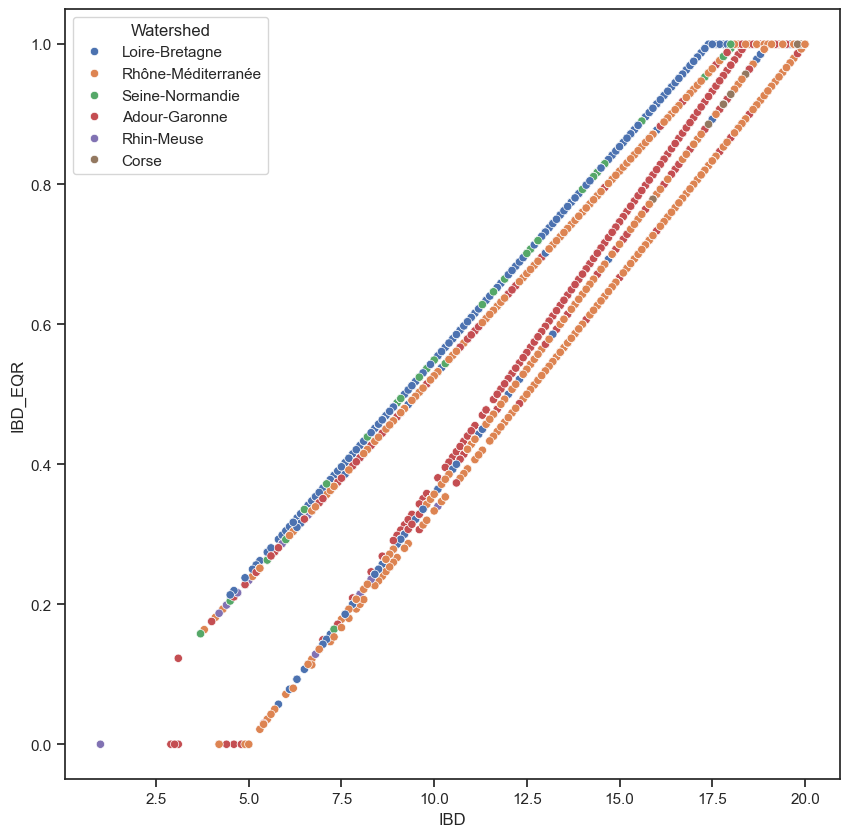

In [12]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=ibd_site, x='IBD', y='IBD_EQR', hue='Watershed')
plt.show()

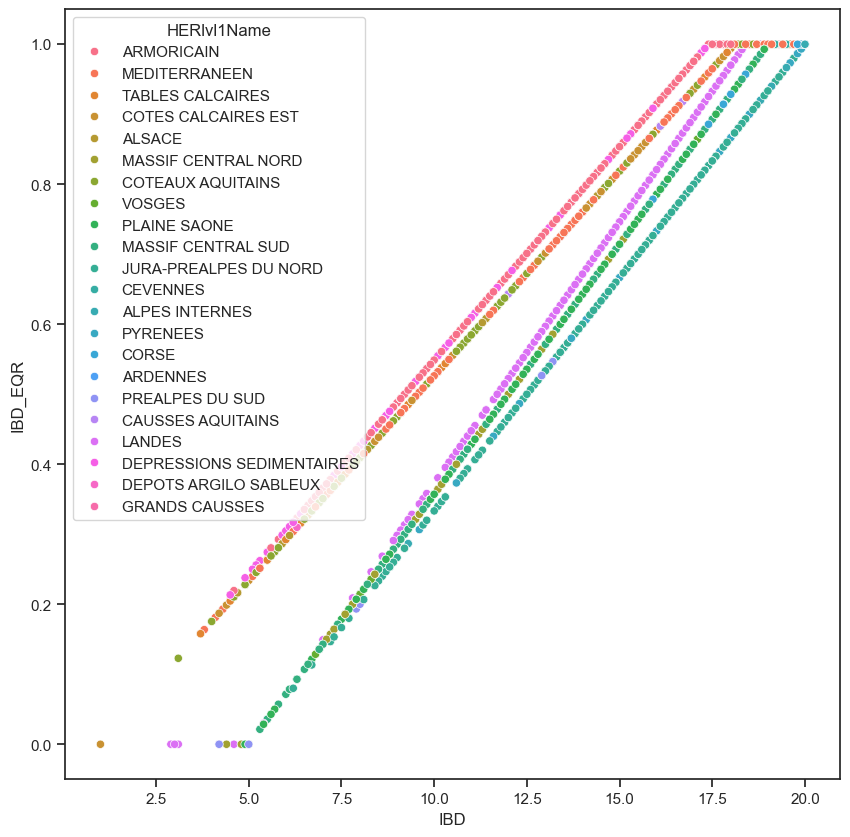

In [13]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=ibd_site, x='IBD', y='IBD_EQR', hue='HERlvl1Name')
plt.show()

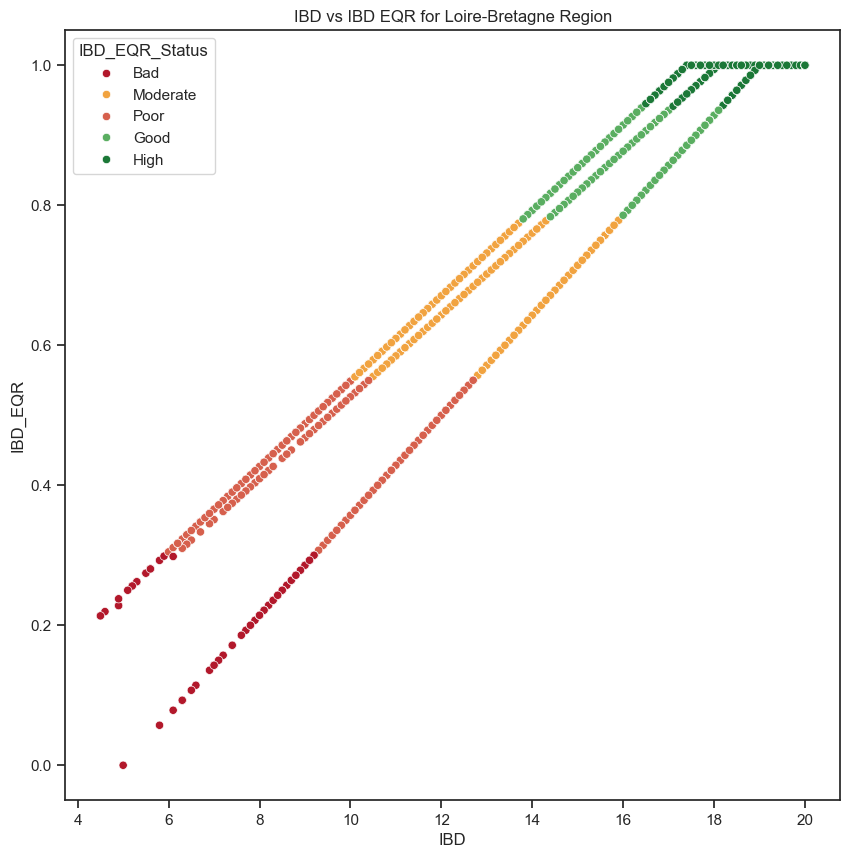

In [14]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=loire, x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', palette=palette)
plt.title('IBD vs IBD EQR for Loire-Bretagne Region')
plt.show()

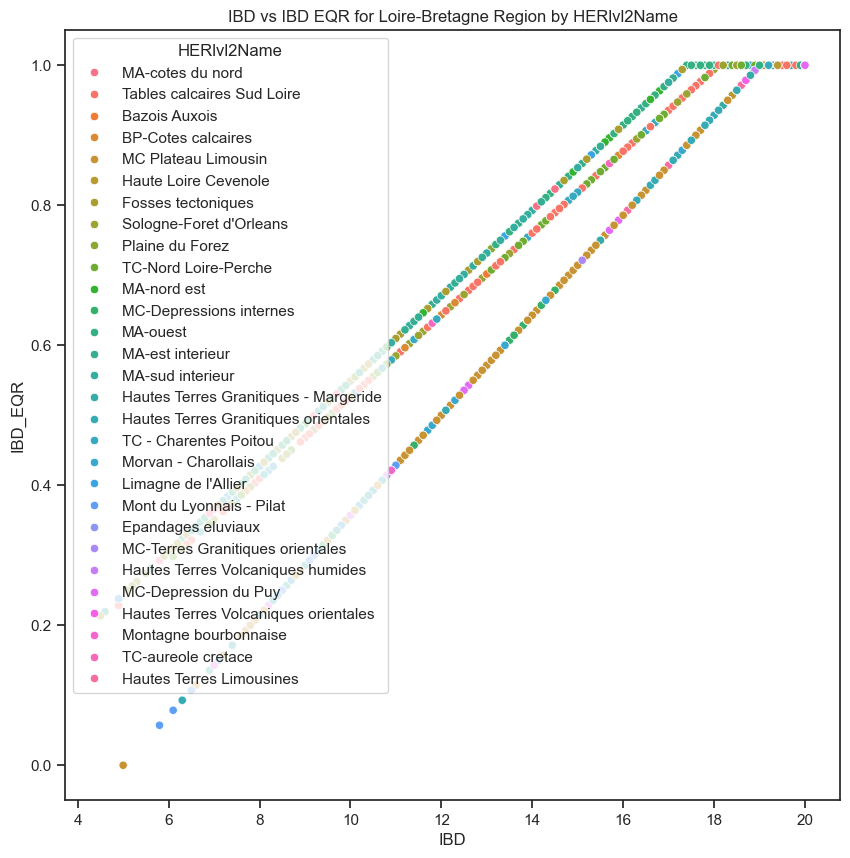

In [15]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=loire, x='IBD', y='IBD_EQR', hue='HERlvl2Name')
plt.title('IBD vs IBD EQR for Loire-Bretagne Region by HERlvl2Name')
plt.show()

## HERlvl1Name

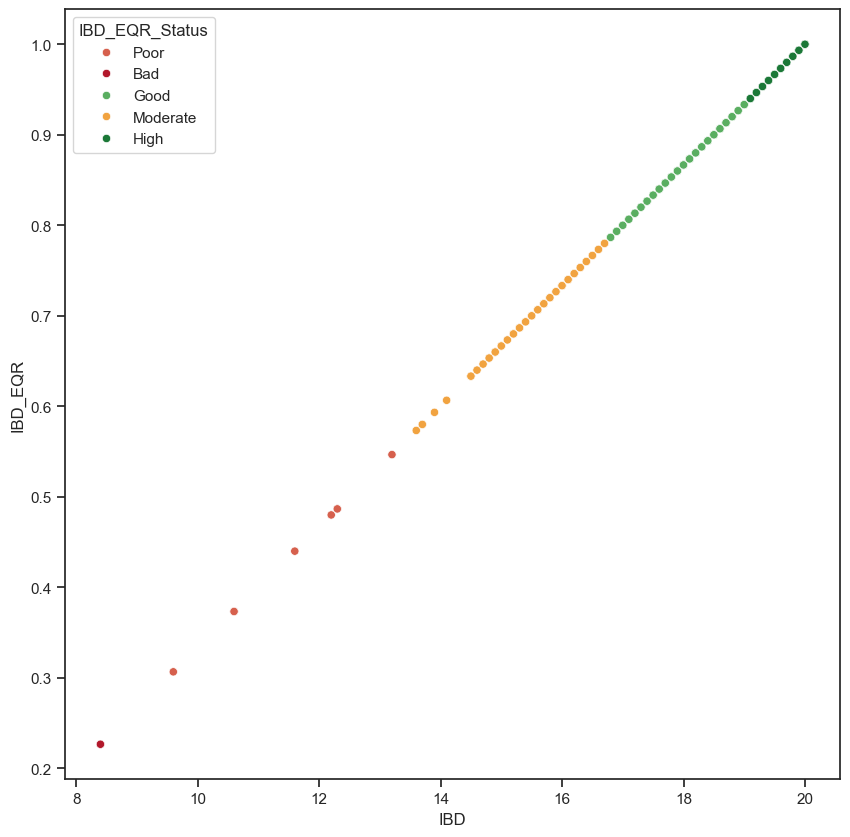

In [16]:
ARMORICAIN = ibd_site[ibd_site["HERlvl1Code"] == 1]
plt.figure(figsize=(10, 10))
sns.scatterplot(data=ARMORICAIN, x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', palette=palette)
plt.show()

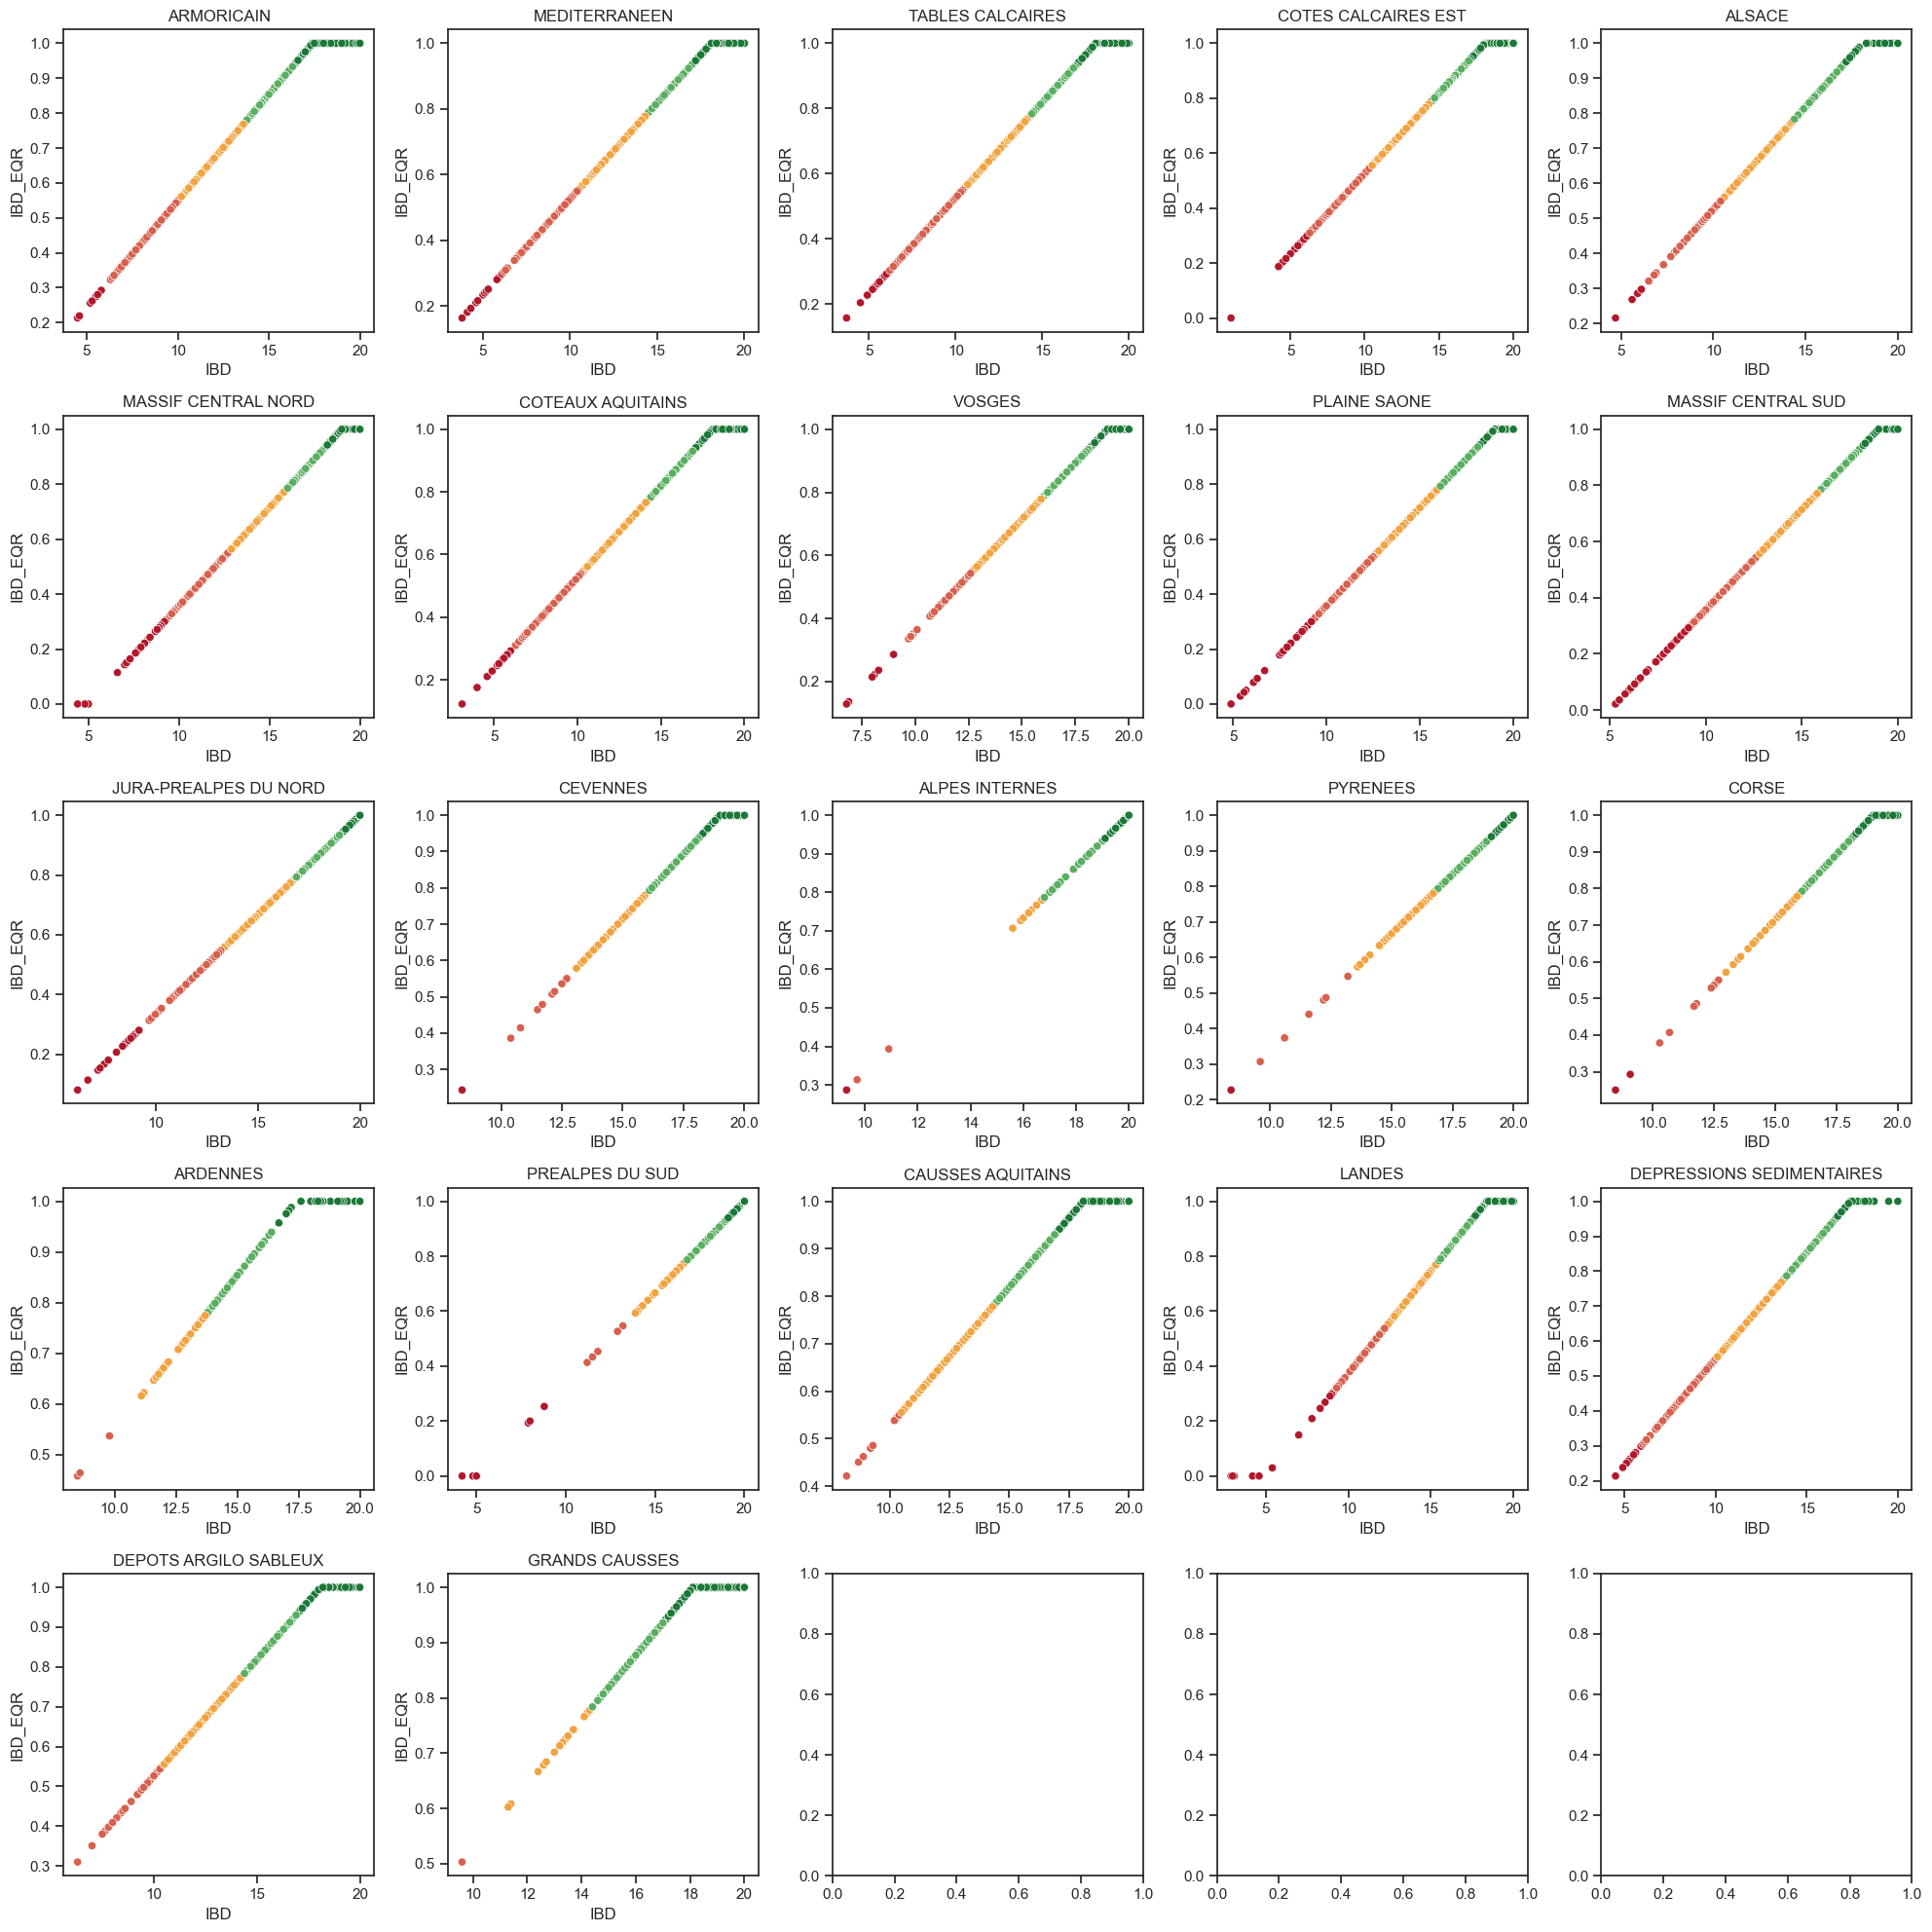

In [17]:
# subplot of 22 plots of each HERlvl1Name
herlvl1names = ibd_site["HERlvl1Name"].unique()
num_names = len(herlvl1names)
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
for i, name in enumerate(herlvl1names):
    ax = axs[i // 5, i % 5]
    sns.scatterplot(data=ibd_site[ibd_site["HERlvl1Name"] == name], x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', ax=ax, palette=palette)
    
    ax.set_title(name)
    ax.legend_.remove()
plt.tight_layout()
plt.show()

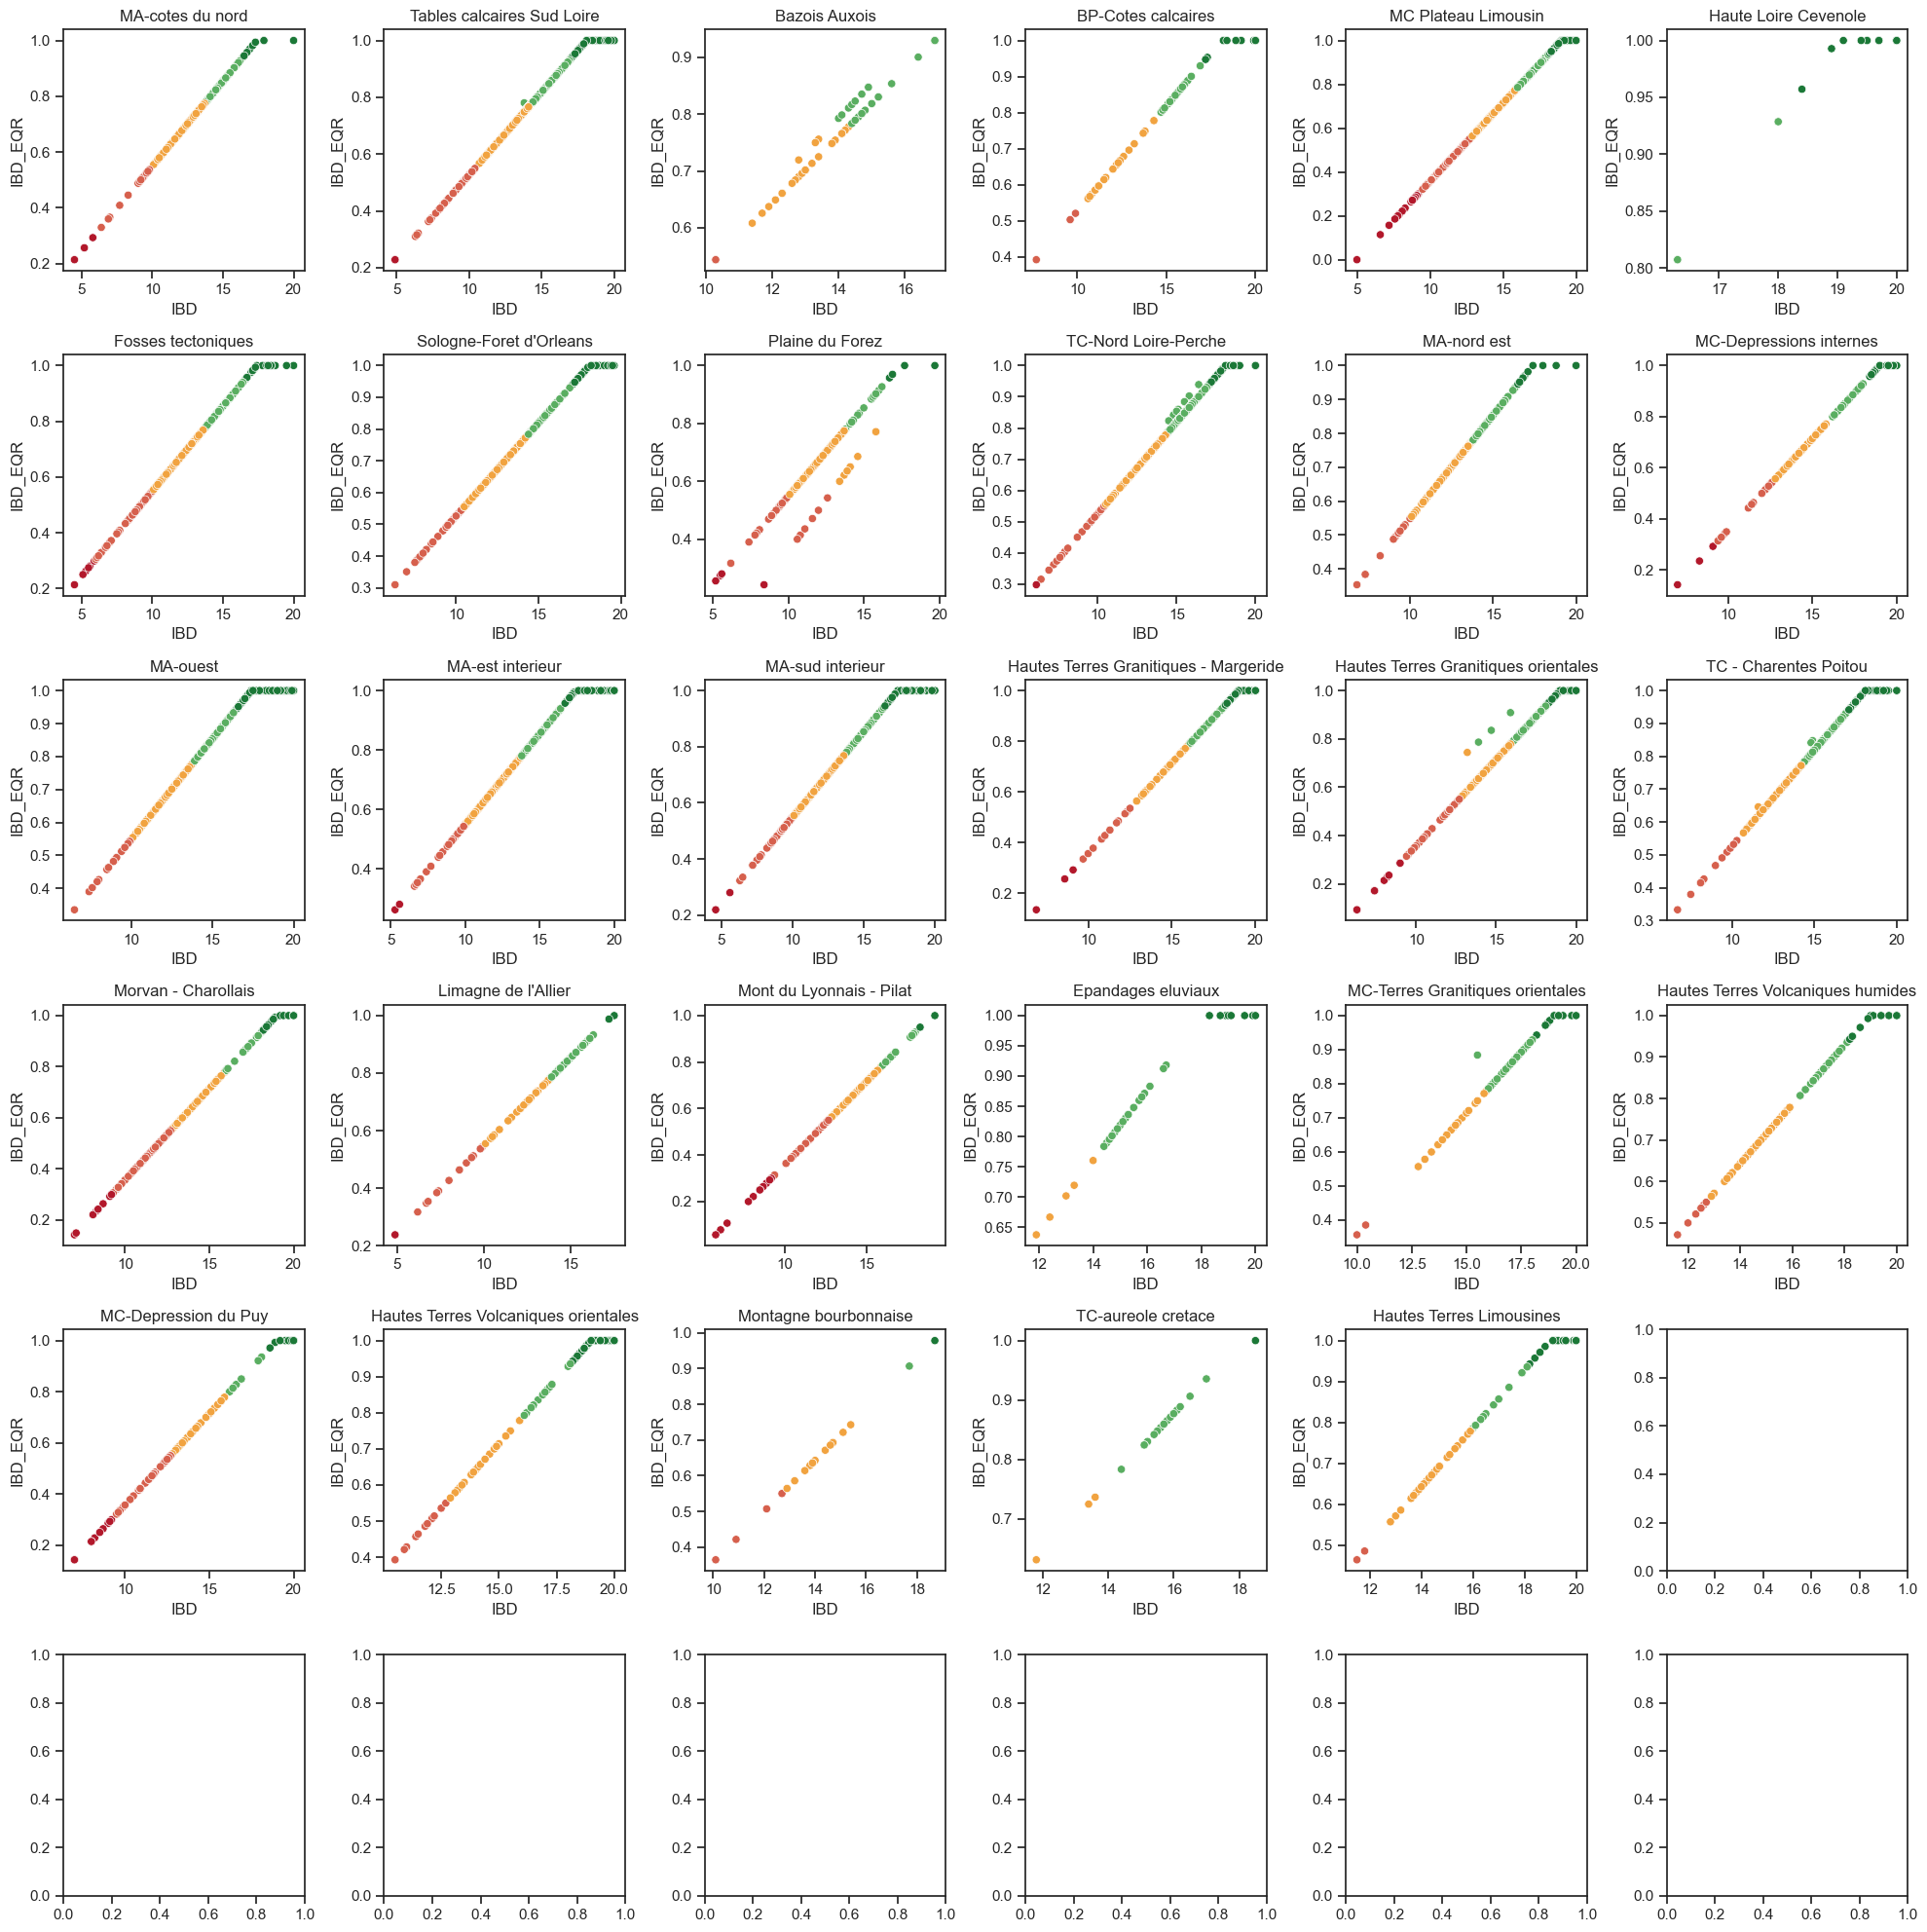

In [18]:
# subplot of 22 plots of each HERlvl1Name
herlvl1names = loire["HERlvl2Name"].unique()
num_names = len(herlvl1names)
fig, axs = plt.subplots(nrows=6, ncols=6, figsize=(20, 20))
for i, name in enumerate(herlvl1names):
    ax = axs[i // 6, i % 6]
    sns.scatterplot(data=loire[loire["HERlvl2Name"] == name], x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', ax=ax, palette=palette)
    
    ax.set_title(name)
    ax.legend_.remove()
plt.tight_layout()
plt.show()

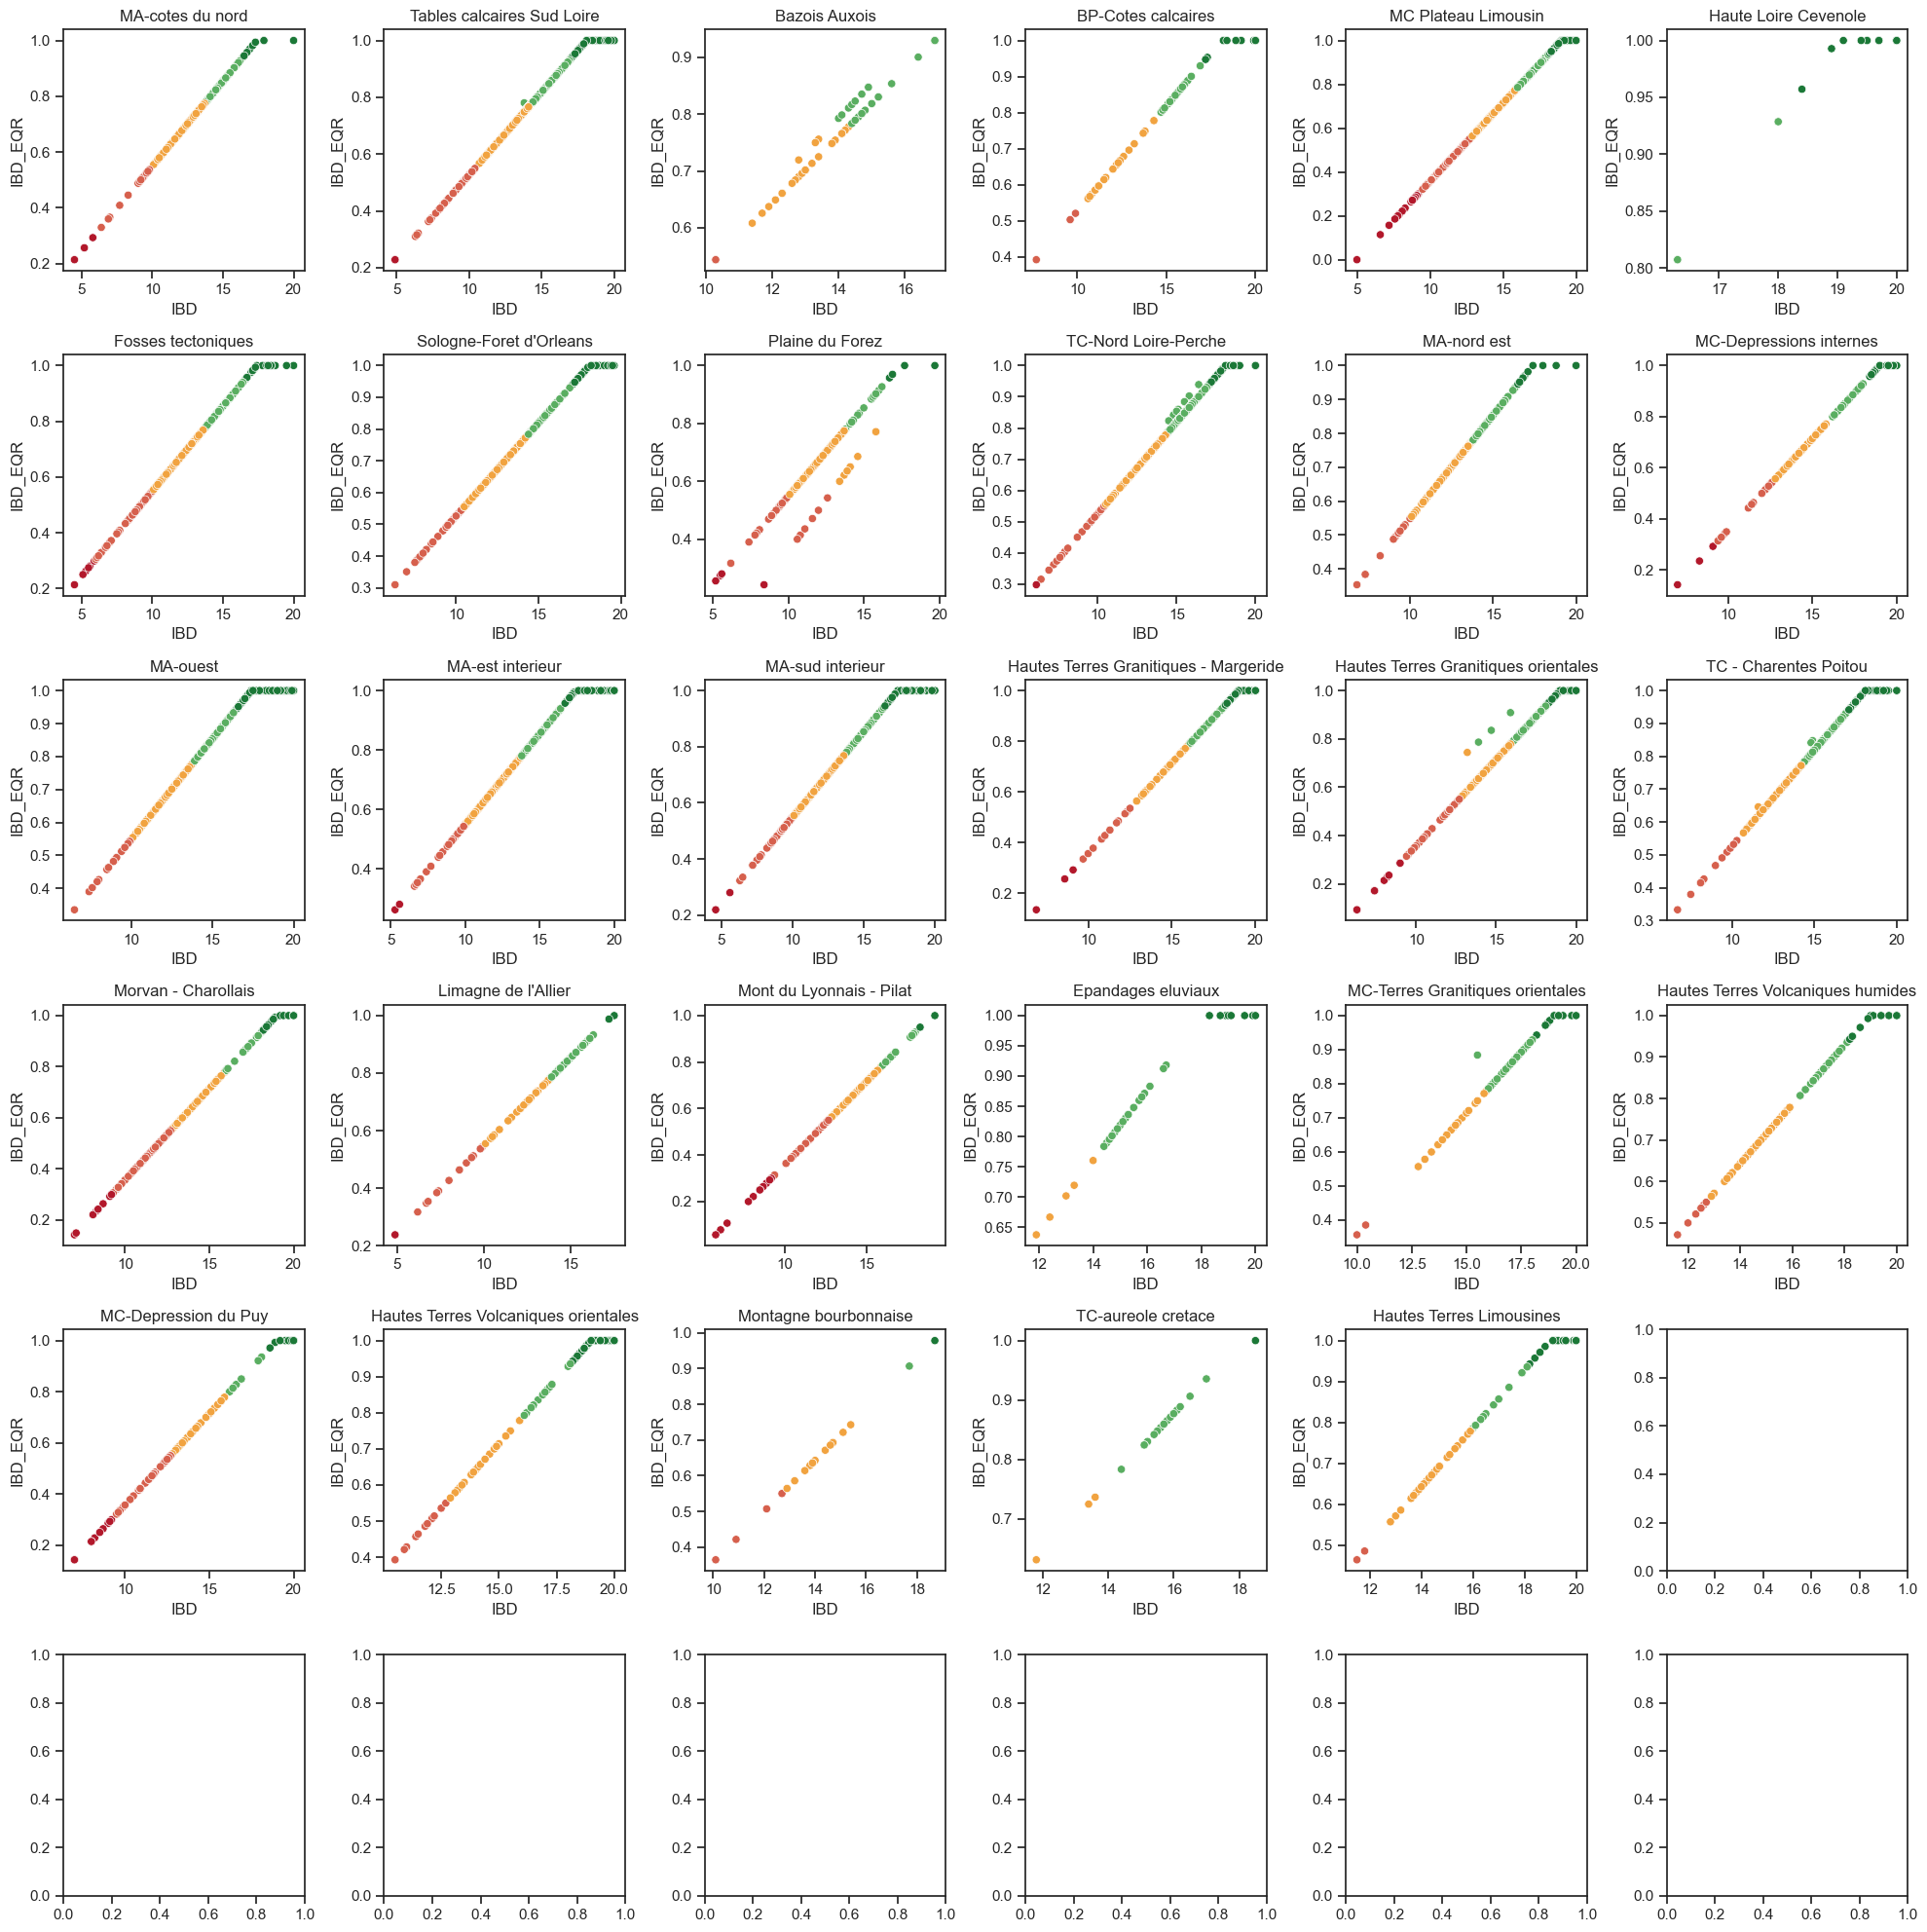

In [19]:
loire = loire[loire["HERlvl2Name"].notna()]
herlvl1names = loire["HERlvl2Name"].unique()
num_names = len(herlvl1names)
fig, axs = plt.subplots(nrows=6, ncols=6, figsize=(20, 20))
for i, name in enumerate(herlvl1names):
    ax = axs[i // 6, i % 6]
    sns.scatterplot(data=loire[loire["HERlvl2Name"] == name], x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', ax=ax, palette=palette)
    
    ax.set_title(name)
    ax.legend_.remove()
plt.tight_layout()
plt.show()

In [26]:
len(ibd_site['HERlvl1Name'].unique())

22

In [28]:
len(loire['HERlvl1Name'].unique())

8

In [35]:
# for each HERlvl1Name, know the range of clasification of the IBD_EQR_Status by the IBD

# example 
# for Amoricain
# IBD range: (0, 7)   -> IBD_EQR_Status: Bad
# IBD range: (7, 12) -> IBD_EQR_Status: Poor
# IBD range: (12, 15) -> IBD_EQR_Status: Moderate
# IBD range: (15, 18) -> IBD_EQR_Status: Good
# IBD range: (18, 20) -> IBD_EQR_Status: High

herlvl1names = ibd_site["HERlvl2Name"].unique()

status_order = ["Bad", "Poor", "Moderate", "Good", "High"]
ranges = []

for name in herlvl1names:
    print(f"HERlvl2Name: {name}")
    herlvl1 = ibd_site[ibd_site["HERlvl2Name"] == name]
    for status in sorted(herlvl1["IBD_EQR_Status"].unique(), key=lambda x: status_order.index(x)):
        status_data = herlvl1[herlvl1["IBD_EQR_Status"] == status]
        if not status_data.empty:
            ibd_min = status_data["IBD"].min()
            ibd_max = status_data["IBD"].max()
            print(f"  IBD range: ({ibd_min}, {ibd_max}) -> IBD_EQR_Status: {status}")
            ranges.append({"HERlvl1Name": name, "IBD_EQR_Status": status, "IBD_min": ibd_min, "IBD_max": ibd_max})
    print("\n")

HERlvl2Name: MA-cotes du nord
  IBD range: (4.5, 5.8) -> IBD_EQR_Status: Bad
  IBD range: (6.4, 9.8) -> IBD_EQR_Status: Poor
  IBD range: (10.1, 13.7) -> IBD_EQR_Status: Moderate
  IBD range: (13.8, 16.4) -> IBD_EQR_Status: Good
  IBD range: (16.5, 20.0) -> IBD_EQR_Status: High


HERlvl2Name: Plaine mediterraneenne
  IBD range: (3.8, 6.1) -> IBD_EQR_Status: Bad
  IBD range: (6.2, 10.4) -> IBD_EQR_Status: Poor
  IBD range: (10.5, 14.3) -> IBD_EQR_Status: Moderate
  IBD range: (14.4, 17.0) -> IBD_EQR_Status: Good
  IBD range: (17.1, 20.0) -> IBD_EQR_Status: High


HERlvl2Name: Cotentin est
  IBD range: (3.7, 3.7) -> IBD_EQR_Status: Bad
  IBD range: (6.2, 10.4) -> IBD_EQR_Status: Poor
  IBD range: (10.5, 14.3) -> IBD_EQR_Status: Moderate
  IBD range: (14.4, 16.7) -> IBD_EQR_Status: Good


HERlvl2Name: Tables calcaires Sud Loire
  IBD range: (4.9, 4.9) -> IBD_EQR_Status: Bad
  IBD range: (6.3, 10.4) -> IBD_EQR_Status: Poor
  IBD range: (10.7, 14.3) -> IBD_EQR_Status: Moderate
  IBD range: 

In [36]:
ranges_df = pd.DataFrame(ranges)
ranges_df

,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max
0,MA-cotes du nord,Bad,4.5,5.8
1,MA-cotes du nord,Poor,6.4,9.8
2,MA-cotes du nord,Moderate,10.1,13.7
3,MA-cotes du nord,Good,13.8,16.4
4,MA-cotes du nord,High,16.5,20.0
...,...,...,...,...
421,Bordure Orientale des Pyrenees,High,19.2,20.0
422,Plateaux calcaires de Provence,Good,18.7,18.7
423,Plateaux calcaires de Provence,High,19.7,20.0
424,Beaujolais calcaire,Good,15.4,16.1


In [37]:
# Create a new column with the middle point of the IBD range
ranges_df["IBD_mid"] = (ranges_df["IBD_min"] + ranges_df["IBD_max"]) / 2
ranges_df

,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
0,MA-cotes du nord,Bad,4.5,5.8,5.15
1,MA-cotes du nord,Poor,6.4,9.8,8.10
2,MA-cotes du nord,Moderate,10.1,13.7,11.90
3,MA-cotes du nord,Good,13.8,16.4,15.10
4,MA-cotes du nord,High,16.5,20.0,18.25
...,...,...,...,...,...
421,Bordure Orientale des Pyrenees,High,19.2,20.0,19.60
422,Plateaux calcaires de Provence,Good,18.7,18.7,18.70
423,Plateaux calcaires de Provence,High,19.7,20.0,19.85
424,Beaujolais calcaire,Good,15.4,16.1,15.75


In [43]:
ranges_df.tail(20)

,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
406,Hautes Terres Volcaniques orientales,Poor,10.5,12.7,11.60
407,Hautes Terres Volcaniques orientales,Moderate,12.9,15.9,14.40
408,Hautes Terres Volcaniques orientales,Good,16.1,18.1,17.10
409,Hautes Terres Volcaniques orientales,High,18.2,20.0,19.10
410,Montagne bourbonnaise,Poor,10.1,12.7,11.40
411,Montagne bourbonnaise,Moderate,12.9,15.4,14.15
412,Montagne bourbonnaise,Good,17.7,17.7,17.70
413,Montagne bourbonnaise,High,18.7,18.7,18.70
414,Dombes,Bad,4.9,8.8,6.85
415,Dombes,Poor,9.3,12.6,10.95


In [40]:
# # Plot the regions of the IBD_min and the IBD_max for each HERlvl1Name and IBD_EQR_Status with the scatterplot of the IBD vs IBD_EQR of the complete ranges
# fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
# for i, name in enumerate(herlvl1names):
#     ax = axs[i // 5, i % 5]
#     sns.scatterplot(data=ibd_site[ibd_site["HERlvl1Name"] == name], x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', ax=ax, palette=palette)
#     name_ranges = ranges_df[ranges_df["HERlvl1Name"] == name]
#     for _, row in name_ranges.iterrows():
#         ax.axvspan(row["IBD_min"], row["IBD_max"], alpha=0.3, label=row["IBD_EQR_Status"], color=palette[row["IBD_EQR_Status"]])
#     ax.set_title(name)
#     # ax.legend_.remove()
# plt.tight_layout()
# plt.show()

# Handling Missing IBD_EQR_Status for HERlvl1Name

Each `HERlvl1Name` should have 5 `IBD_EQR_Status` values: Bad, Poor, Moderate, Good, and High. However, some `HERlvl1Name` entries are missing one or more statuses. We need to add the missing statuses.

### Example:
For `HERlvl1Name: ALPES INTERNES`, the current ranges are:
- `IBD range: (0.0, 7.0)` -> `IBD_EQR_Status: Bad`, `IBD_mid: 3.5`
- `IBD range: (7.5, 12.0)` -> `IBD_EQR_Status: Poor`, `IBD_mid: 9.75`
- `IBD range: (15.5, 18.0)` -> `IBD_EQR_Status: Good`, `IBD_mid: 16.75`
- `IBD range: (18.0, 20.0)` -> `IBD_EQR_Status: High`, `IBD_mid: 19`

The `Moderate` status is missing!

### Steps to Add Missing Statuses:
1. **Create the Missing Range**:
    - Calculate the middle point between the `IBD_max` of the previous status and the `IBD_min` of the next status.
    - Assign this value as the `IBD_mid`.

    For example:
    - `IBD range: (7.5, 12.0)` -> `IBD_EQR_Status: Poor`, `IBD_mid: 9.75`
    - `IBD range: (15.5, 18.0)` -> `IBD_EQR_Status: Good`, `IBD_mid: 16.75`
    - Missing `IBD_EQR_Status: Moderate`, `IBD_mid: 13.75`

2. **Calculate the New Range**:
    - Compute the `IBD_min` as the midpoint between the new `IBD_mid` and the previous `IBD_max`.
    - Compute the `IBD_max` as the midpoint between the new `IBD_mid` and the next `IBD_min`.

    For example:
    - `IBD_EQR_Status: Moderate`, `IBD_mid: 13.75`
    - `IBD_min = (13.75 + 12) / 2 = 12.875`
    - `IBD_max = (13.75 + 15.5) / 2 = 14.625`

    The new range becomes:
    - `IBD range: (12.875, 14.625)` -> `IBD_EQR_Status: Moderate`, `IBD_mid: 13.75`

3. **Update the DataFrame**:
    - Add the new range to the dataframe.
    - Sort the dataframe by `HERlvl1Name` and in the order of `IBD_EQR_Status`: Bad, Poor, Moderate, Good, High.

In [41]:
import pandas as pd

STATUS_ORDER = ['Bad', 'Poor', 'Moderate', 'Good', 'High']
ORDER_IDX = {s: i for i, s in enumerate(STATUS_ORDER)}

def _fill_group(g: pd.DataFrame, lo: float = 0.0, hi: float = 20.0) -> pd.DataFrame:
    g = g.copy()
    # keep originals
    orig = {row.IBD_EQR_Status: (float(row.IBD_min), float(row.IBD_max))
            for _, row in g.iterrows()}
    data = orig.copy()

    # add missing statuses using midpoint rule
    while len(data) < 5:
        for s in STATUS_ORDER:
            if s in data:
                continue
            i = ORDER_IDX[s]
            prev = next((STATUS_ORDER[j] for j in range(i-1, -1, -1) if STATUS_ORDER[j] in data), None)
            nxt  = next((STATUS_ORDER[j] for j in range(i+1, 5)   if STATUS_ORDER[j] in data), None)

            prev_max = data[prev][1] if prev else lo
            next_min = data[nxt][0]  if nxt  else hi

            mid = 0.5 * (prev_max + next_min)
            new_min = 0.5 * (prev_max + mid)
            new_max = 0.5 * (mid + next_min)
            data[s] = (new_min, new_max)

    # assemble rows, preserving originals where they existed
    her = g['HERlvl1Name'].iloc[0]
    rows = []
    for s in STATUS_ORDER:
        mn, mx = (orig[s] if s in orig else data[s])
        rows.append({
            'HERlvl1Name': her,
            'IBD_EQR_Status': s,
            'IBD_min': mn,
            'IBD_max': mx,
            'IBD_mid': 0.5 * (mn + mx)
        })
    return pd.DataFrame(rows)

def fill_missing_statuses(ranges_df: pd.DataFrame, scale_low: float = 0.0, scale_high: float = 20.0) -> pd.DataFrame:
    out = ranges_df.groupby('HERlvl1Name', group_keys=False).apply(
        lambda g: _fill_group(g, scale_low, scale_high)
    )
    out['IBD_EQR_Status'] = pd.Categorical(out['IBD_EQR_Status'],
                                           categories=STATUS_ORDER, ordered=True)
    out = out.sort_values(['HERlvl1Name', 'IBD_EQR_Status']).reset_index(drop=True)
    return out

# usage
filled = fill_missing_statuses(ranges_df, scale_low=0.0, scale_high=20.0)

# optional sanity check
assert filled.groupby('HERlvl1Name')['IBD_EQR_Status'].nunique().eq(5).all()
filled


C:\Users\herie\AppData\Local\Temp\ipykernel_16868\4289787506.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = ranges_df.groupby('HERlvl1Name', group_keys=False).apply(


,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
0,Alpes Internes du Sud,Bad,4.0500,12.1500,8.100
1,Alpes Internes du Sud,Poor,13.1625,15.1875,14.175
2,Alpes Internes du Sud,Moderate,16.2000,16.5000,16.350
3,Alpes Internes du Sud,Good,17.1000,18.4000,17.750
4,Alpes Internes du Sud,High,19.1000,20.0000,19.550
...,...,...,...,...,...
525,Vosges greseuses,Bad,8.1000,9.0000,8.550
526,Vosges greseuses,Poor,9.7000,12.7000,11.200
527,Vosges greseuses,Moderate,12.8000,15.9000,14.350
528,Vosges greseuses,Good,16.1000,18.1000,17.100


In [42]:
filled[filled['HERlvl1Name'] == 'Massif du Mont Blanc']

,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
345,Massif du Mont Blanc,Bad,5.000000,15.000000,10.00000
346,Massif du Mont Blanc,Poor,16.250000,18.750000,17.50000
347,Massif du Mont Blanc,Moderate,19.062500,19.687500,19.37500
348,Massif du Mont Blanc,Good,19.765625,19.921875,19.84375
349,Massif du Mont Blanc,High,20.000000,20.000000,20.00000


# Making IBD_EQR_Status Ranges Continuous for HERlvl1Name

After filling the missing `IBD_EQR_Status` values for each `HERlvl1Name`, the next step is to ensure that the `IBD_min` and `IBD_max` ranges are continuous. This means there should be no gaps between the ranges of consecutive statuses.

### Example:
For `HERlvl1Name: ALPES INTERNES`, the current ranges after filling missing statuses might look like this:
- `IBD range: (0.0, 7.0)` -> `IBD_EQR_Status: Bad`, `IBD_mid: 3.5`
- `IBD range: (7.5, 12.0)` -> `IBD_EQR_Status: Poor`, `IBD_mid: 9.75`
- `IBD range: (12.875, 14.625)` -> `IBD_EQR_Status: Moderate`, `IBD_mid: 13.75`
- `IBD range: (15.5, 18.0)` -> `IBD_EQR_Status: Good`, `IBD_mid: 16.75`
- `IBD range: (18.0, 20.0)` -> `IBD_EQR_Status: High`, `IBD_mid: 19`

Notice the gaps between the ranges:
- Between `Bad` and `Poor`: `(7.0, 7.5)`
- Between `Poor` and `Moderate`: `(12.0, 12.875)`
- Between `Moderate` and `Good`: `(14.625, 15.5)`

### Steps to Make Ranges Continuous:
1. **Calculate New Boundaries**:
    - Use the midpoints of adjacent `IBD_mid` values to define the new boundaries.
    - The boundaries are calculated as follows:
        - `b1 = midpoint(IBD_mid[0], IBD_mid[1])`
        - `b2 = midpoint(IBD_mid[1], IBD_mid[2])`
        - And so on.

2. **Update Ranges**:
    - Set the `IBD_min` of each status to the lower boundary of its range.
    - Set the `IBD_max` of each status to the upper boundary of its range.

3. **Update the DataFrame**:
    - Apply the changes to the dataframe for each `HERlvl1Name`.

### Final Output:
The updated ranges for `HERlvl1Name: ALPES INTERNES` will look like this:
- `IBD range: (0.0, 7.25)` -> `IBD_EQR_Status: Bad`, `IBD_mid: 3.5`
- `IBD range: (7.25, 12.4375)` -> `IBD_EQR_Status: Poor`, `IBD_mid: 9.75`
- `IBD range: (12.4375, 15.125)` -> `IBD_EQR_Status: Moderate`, `IBD_mid: 13.75`
- `IBD range: (15.125, 18.0)` -> `IBD_EQR_Status: Good`, `IBD_mid: 16.75`
- `IBD range: (18.0, 20.0)` -> `IBD_EQR_Status: High`, `IBD_mid: 19`

This ensures that the ranges are continuous and there are no gaps between consecutive statuses.

In [32]:
import numpy as np
import pandas as pd

STATUS_ORDER = ['Bad', 'Poor', 'Moderate', 'Good', 'High']

def make_continuous_by_midpoint(df: pd.DataFrame, low: float | None = None, high: float | None = None) -> pd.DataFrame:
    df = df.copy()
    df['IBD_EQR_Status'] = pd.Categorical(df['IBD_EQR_Status'],
                                          categories=STATUS_ORDER, ordered=True)

    def _group(g: pd.DataFrame) -> pd.DataFrame:
        g = g.sort_values('IBD_EQR_Status').reset_index(drop=True)
        if len(g) != 5:
            raise ValueError(f"{g['HERlvl1Name'].iloc[0]} has {len(g)} rows; expected 5. Fill first.")

        m = g['IBD_mid'].to_numpy(dtype=float)
        lo = g['IBD_min'].min() if low is None else float(low)
        hi = g['IBD_max'].max() if high is None else float(high)

        # boundaries: [b0, b1, b2, b3, b4, b5] with b1..b4 = midpoints of adjacent mids
        b = np.empty(6, dtype=float)
        b[0], b[5] = lo, hi
        b[1:5] = 0.5 * (m[:-1] + m[1:])

        g['IBD_min'] = b[:-1]
        g['IBD_max'] = b[1:]
        return g

    out = df.groupby('HERlvl1Name', group_keys=False).apply(_group)
    return out.reset_index(drop=True)

# example:
# filled = fill_missing_statuses(ranges_df, scale_low=0.0, scale_high=20.0)  # from previous step
continuous = make_continuous_by_midpoint(filled, low=0.0, high=20.0)
continuous

C:\Users\herie\AppData\Local\Temp\ipykernel_16868\3750341964.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby('HERlvl1Name', group_keys=False).apply(_group)


,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
0,ALPES INTERNES,Bad,0.000,9.800,9.30
1,ALPES INTERNES,Poor,9.800,13.225,10.30
2,ALPES INTERNES,Moderate,13.225,17.025,16.15
3,ALPES INTERNES,Good,17.025,18.725,17.90
4,ALPES INTERNES,High,18.725,20.000,19.55
...,...,...,...,...,...
105,VOSGES,Bad,0.000,9.550,7.90
106,VOSGES,Poor,9.550,12.775,11.20
107,VOSGES,Moderate,12.775,15.700,14.35
108,VOSGES,Good,15.700,18.075,17.05


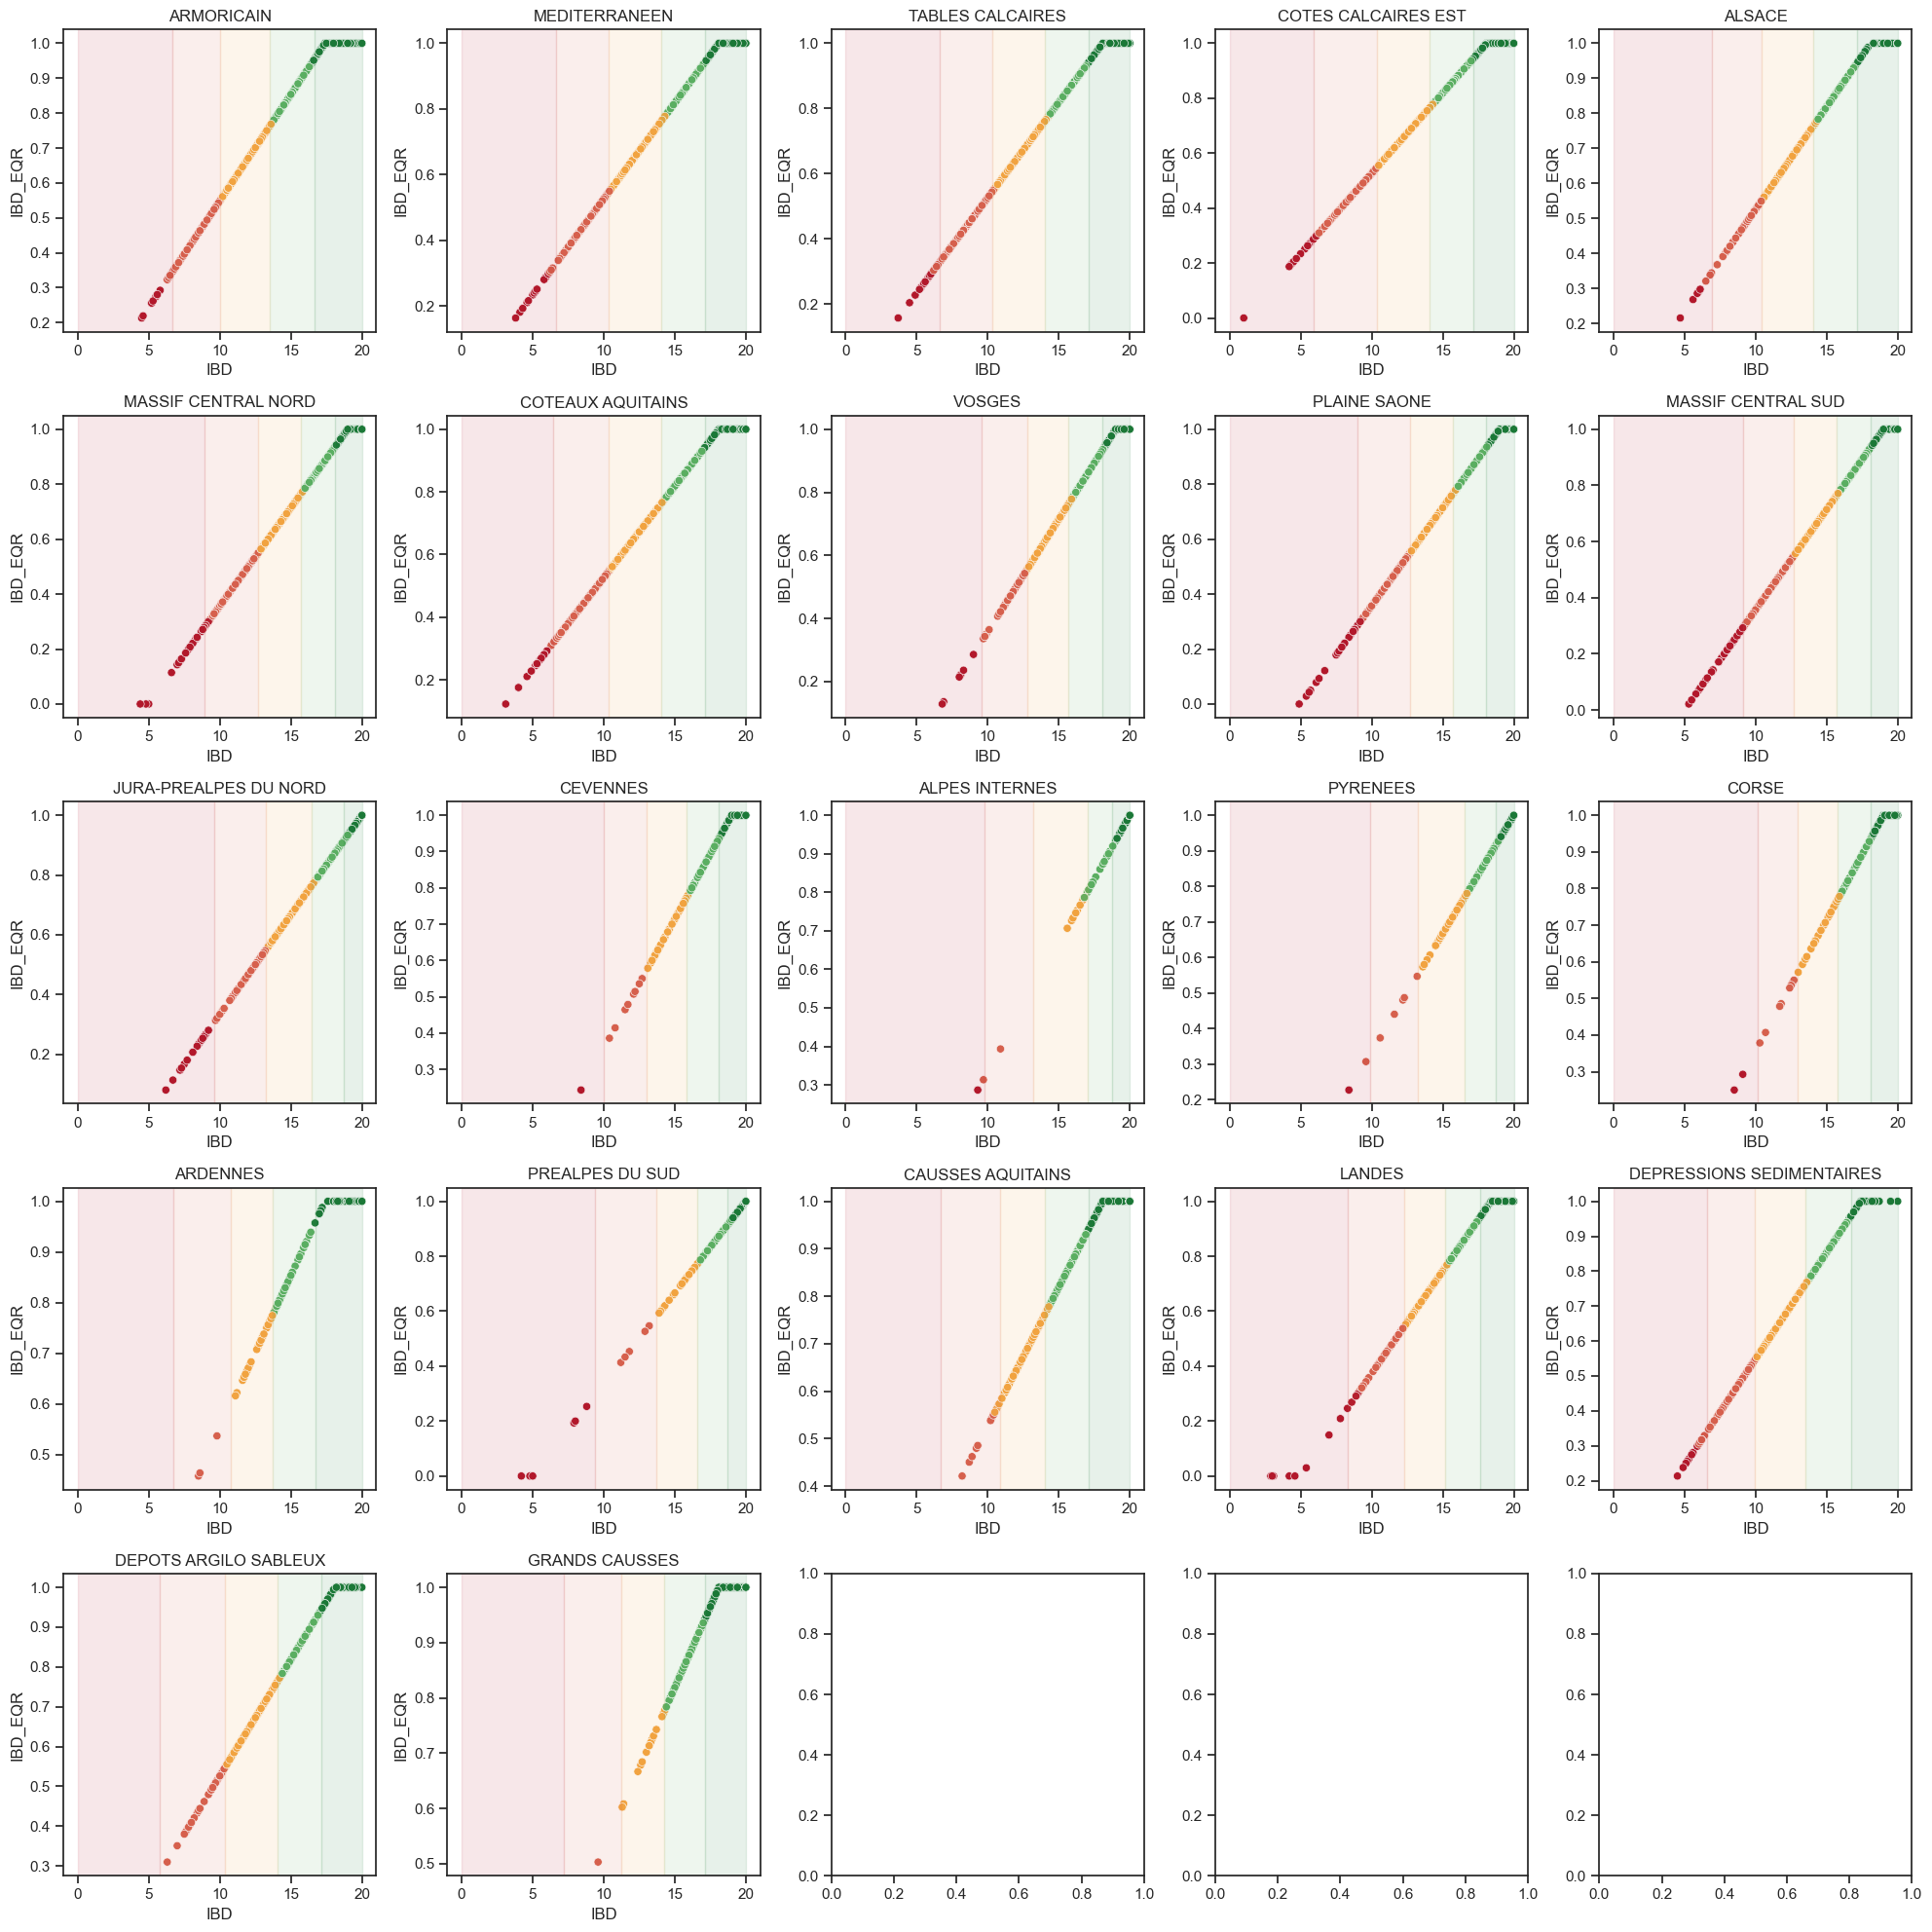

In [33]:
# Plot the regions of the IBD_min and the IBD_max for each HERlvl1Name and IBD_EQR_Status with the scatterplot of the IBD vs IBD_EQR of the complete ranges
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
for i, name in enumerate(herlvl1names):
    ax = axs[i // 5, i % 5]
    sns.scatterplot(data=ibd_site[ibd_site["HERlvl1Name"] == name], x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', ax=ax, palette=palette)
    name_ranges = continuous[continuous["HERlvl1Name"] == name]
    for _, row in name_ranges.iterrows():
        ax.axvspan(row["IBD_min"], row["IBD_max"], alpha=0.1, label=row["IBD_EQR_Status"], color=palette[row["IBD_EQR_Status"]])
    ax.set_title(name)
    ax.legend_.remove()
plt.tight_layout()
plt.show()

In [34]:
# save to csv
continuous.to_csv("../../data/processed/ibd_eqr_ranges_by_herlvl1_continuous_midpoint.csv", index=False)